1. engines number
2. cycles operated perfectly
3. engine temp

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

/home/shakhawat/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [3]:
# Define Column Names
index_names = ['unit_number', 'time_cycles']
operational_settings = ['setting_1', 'setting_2', 'setting_3']
# Grouping sensors helps in readability (Physical meanings)
sensor_names = [
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',        # Temperatures & Pressures
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',       # Rotational Speeds
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32' # Others
]
col_names = index_names + operational_settings + sensor_names
print(f"Column names defined. Total columns: {len(col_names)}")

Column names defined. Total columns: 26


In [4]:
data = pd.read_csv("train_FD001.txt", sep=r"\s+" , header=None, names=col_names)
data.shape

(20631, 26)

In [5]:
print("=" * 5 + " First 5 Data " + 5 * "=")
print(data.head())
print("=" * 5 + " Last 5 Data " + 5 * "=")
print(data.tail())

===== First 5 Data =====
   unit_number  time_cycles  setting_1  setting_2  setting_3      T2     T24  \
0            1            1    -0.0007    -0.0004      100.0  518.67  641.82   
1            1            2     0.0019    -0.0003      100.0  518.67  642.15   
2            1            3    -0.0043     0.0003      100.0  518.67  642.35   
3            1            4     0.0007     0.0000      100.0  518.67  642.35   
4            1            5    -0.0019    -0.0002      100.0  518.67  642.37   

       T30      T50     P2  ...     phi      NRf      NRc     BPR  farB  \
0  1589.70  1400.60  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03   
1  1591.82  1403.14  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03   
2  1587.99  1404.20  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03   
3  1582.79  1401.87  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03   
4  1582.85  1406.22  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03   

   htBleed  Nf_dmd  PCNfR_dmd    W31      W

In [6]:
print("Missing Values in Train:", data.isnull().sum().sum())

Missing Values in Train: 0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   T2           20631 non-null  float64
 6   T24          20631 non-null  float64
 7   T30          20631 non-null  float64
 8   T50          20631 non-null  float64
 9   P2           20631 non-null  float64
 10  P15          20631 non-null  float64
 11  P30          20631 non-null  float64
 12  Nf           20631 non-null  float64
 13  Nc           20631 non-null  float64
 14  epr          20631 non-null  float64
 15  Ps30         20631 non-null  float64
 16  phi          20631 non-null  float64
 17  NRf          20631 non-null  float64
 18  NRc          20631 non-null  float64
 19  BPR 

In [8]:
# Statistical Information
data.describe().T
# Here setting_3 constant value, so it has no value.

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
T2,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
T24,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
T30,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
T50,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
P2,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [9]:
constant_features = []

for col in data.columns:
    unique_count = data[col].nunique()

    if unique_count <= 1:
        constant_features.append(col)
print(f"Constant Features: {constant_features}")

Constant Features: ['setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']


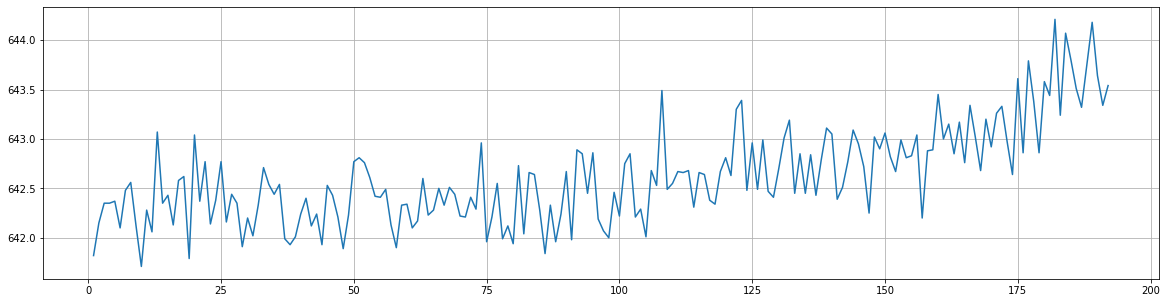

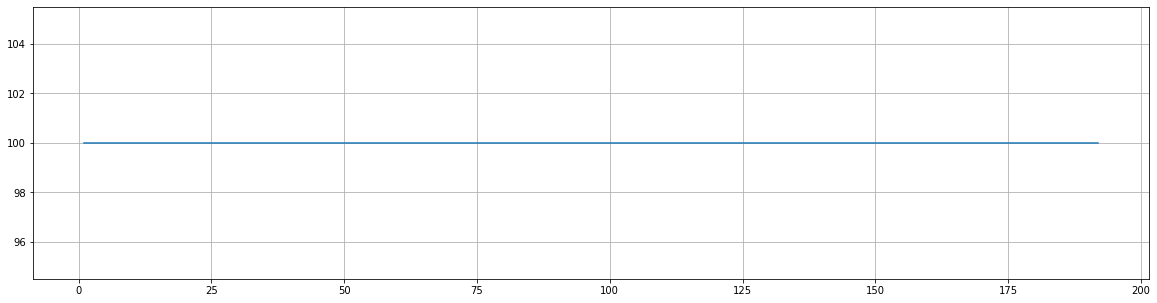

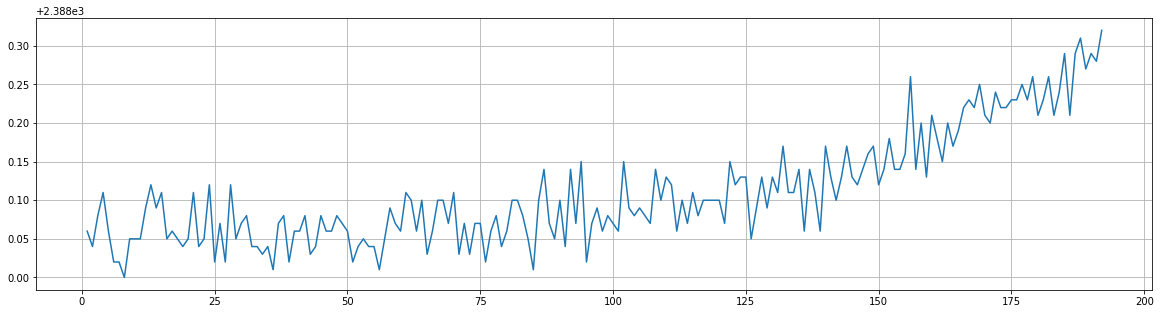

In [11]:
engine_1 = data[data['unit_number'] == 1]
x = engine_1["time_cycles"]
y1 = engine_1["T24"]
y2 = engine_1["setting_3"]
y3 = engine_1["Nf"]

plt.figure(figsize=(20, 5))
plt.plot(x, y1)
plt.grid()
plt.show()

plt.figure(figsize=(20, 5))
plt.plot(x, y2)
plt.grid()
plt.show()

plt.figure(figsize=(20, 5))
plt.plot(x, y3)
plt.grid()
plt.show()
